In [1]:
# ═══════════════════════════════════════════════════
# CELL 1 — Installs
# ═══════════════════════════════════════════════════
!pip install -q semantic-kernel google-genai datasets scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.0/924.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.9/217.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.6/106.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — Imports + API setup
# ═══════════════════════════════════════════════════
import re, time, csv, getpass
import numpy as np
from collections import defaultdict
from google import genai
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from semantic_kernel import Kernel
from semantic_kernel.functions import kernel_function, KernelArguments

API_KEY = getpass.getpass("Enter Gemini API key: ")
client  = genai.Client(api_key=API_KEY)

Enter Gemini API key: ··········


In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — Gemini call with retry backoff
# ═══════════════════════════════════════════════════
def ask_gemini(prompt: str, retries: int = 3, wait: float = 5.0) -> str:
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash", contents=prompt
            )
            return response.text.strip()
        except Exception as e:
            print(f"  [API error attempt {attempt+1}/{retries}]: {e}")
            if attempt < retries - 1:
                time.sleep(wait * (attempt + 1))
    return ""

In [4]:

# ═══════════════════════════════════════════════════
# CELL 3.5 — Solution RAG: TF-IDF over ARC train
# ═══════════════════════════════════════════════════
print("Building solution RAG index from ARC-Challenge train split...")
train_ds = load_dataset("ai2_arc", "ARC-Challenge", split="train")

def format_arc_sample(s):
    choices    = s["choices"]["text"]
    labels     = s["choices"]["label"]
    choice_str = "\n".join(f"{l}. {t}" for l, t in zip(labels, choices))
    return f"{s['question']}\n{choice_str}", f"Answer: {s['answerKey']}"

train_questions = [format_arc_sample(s)[0] for s in train_ds]
train_answers   = [format_arc_sample(s)[1] for s in train_ds]

vectorizer   = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(train_questions)
print(f"Solution RAG ready: {len(train_questions)} examples indexed.")

def retrieve_examples(query: str, top_k: int = 3) -> str:
    q_vec   = vectorizer.transform([query])
    sims    = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    return "\n\n---\n\n".join(
        f"Example Problem:\n{train_questions[i]}\n{train_answers[i]}"
        for i in top_idx
    )


Building solution RAG index from ARC-Challenge train split...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ARC-Challenge/train-00000-of-00001.parqu(…):   0%|          | 0.00/190k [00:00<?, ?B/s]

ARC-Challenge/test-00000-of-00001.parque(…):   0%|          | 0.00/204k [00:00<?, ?B/s]

ARC-Challenge/validation-00000-of-00001.(…):   0%|          | 0.00/55.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1119 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

Solution RAG ready: 1119 examples indexed.


In [5]:







# ═══════════════════════════════════════════════════
# CELL 3.6 — Failure Pattern RAG (self-growing memory)
# ═══════════════════════════════════════════════════
failure_memory = []

FAILURE_TYPES = ["ARITHMETIC_ERROR", "MISREAD_PROBLEM",
                 "MISSING_CONSTRAINT", "LOGIC_GAP"]

def add_failure(question, wrong_answer, failure_type, reason, correct_answer=None):
    failure_memory.append({
        "question": question, "wrong_answer": wrong_answer,
        "failure_type": failure_type, "reason": reason,
        "correct_answer": correct_answer
    })

def retrieve_similar_failures(query: str, top_k: int = 2) -> str:
    if not failure_memory:
        return ""
    fm_mat  = vectorizer.transform([f["question"] for f in failure_memory])
    q_vec   = vectorizer.transform([query])
    sims    = cosine_similarity(q_vec, fm_mat).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    blocks  = []
    for idx in top_idx:
        f = failure_memory[idx]
        blk = (f"Past Failure [{f['failure_type']}]:\n"
               f"Problem   : {f['question']}\n"
               f"Wrong Ans : {f['wrong_answer']}\n"
               f"Why Wrong : {f['reason']}\n")
        if f["correct_answer"]:
            blk += f"Correct   : {f['correct_answer']}"
        blocks.append(blk)
    return "\n\n---\n\n".join(blocks)

In [6]:

# ═══════════════════════════════════════════════════
# CELL 4 — Targeted recovery prompts
# ═══════════════════════════════════════════════════
RECOVERY_PROMPTS = {
    "ARITHMETIC_ERROR": """You are a reasoning recovery agent. The model made a CALCULATION MISTAKE.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
Redo any calculations from scratch. Show each step.
Answer with ONLY the letter (A, B, C, or D) on the last line.""",

    "MISREAD_PROBLEM": """You are a reasoning recovery agent. The model MISUNDERSTOOD THE QUESTION.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
Re-read the question carefully. Identify exactly what is being asked.
Answer with ONLY the letter (A, B, C, or D) on the last line.""",

    "MISSING_CONSTRAINT": """You are a reasoning recovery agent. The model IGNORED A CONSTRAINT.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
List every constraint in the problem before answering.
Answer with ONLY the letter (A, B, C, or D) on the last line.""",

    "LOGIC_GAP": """You are a reasoning recovery agent. The model had a FLAWED REASONING CHAIN.
Problem: {task}
Wrong Output: {output}
Feedback: {reason}
Rebuild the reasoning chain step by step from scratch.
Answer with ONLY the letter (A, B, C, or D) on the last line.""",
}

In [7]:










# ═══════════════════════════════════════════════════
# CELL 5 — Agent definitions + kernel registration
# ═══════════════════════════════════════════════════
kernel = Kernel()

@kernel_function(name="execution_agent",
                 description="Answers an ARC multiple choice question with RAG context")
def execution_agent(task: str, feedback: str = "") -> str:
    rag_ctx = retrieve_examples(task, top_k=3)
    prompt  = f"""You are a science reasoning assistant. Use the worked examples below as a guide.
Analyze the question carefully and select the best answer.
Answer with ONLY the letter (A, B, C, or D) on the last line.

=== Relevant Examples ===
{rag_ctx}

=== New Question ===
{task}
{"=== Feedback from previous attempt ===\n" + feedback if feedback else ""}
"""
    return ask_gemini(prompt)

@kernel_function(name="verification_agent",
                 description="Placeholder — hybrid_verify is used instead")
def verification_agent(task: str, output: str) -> str:
    return "VALID"

@kernel_function(name="classifier_agent",
                 description="Classifies the failure type of a wrong answer")
def classifier_agent(task: str, output: str, reason: str) -> str:
    prompt = f"""Classify this reasoning failure into exactly one category.

Problem     : {task}
Wrong Output: {output}
Failure Note: {reason}

Categories (pick ONLY one):
- ARITHMETIC_ERROR    : Correct approach but wrong calculation
- MISREAD_PROBLEM     : Misunderstood what the problem is asking
- MISSING_CONSTRAINT  : Ignored a condition or constraint in the problem
- LOGIC_GAP           : Correct facts but flawed reasoning chain

Respond with ONLY the category name, nothing else.
"""
    raw = ask_gemini(prompt).strip().upper()
    return raw if raw in FAILURE_TYPES else "LOGIC_GAP"

@kernel_function(name="recovery_agent",
                 description="Targeted recovery using failure type and past failure memory")
def recovery_agent(task: str, output: str, reason: str, failure_type: str) -> str:
    template   = RECOVERY_PROMPTS.get(failure_type, RECOVERY_PROMPTS["LOGIC_GAP"])
    past_fails = retrieve_similar_failures(task, top_k=2)
    past_block = (f"\n=== Similar Past Failures ===\n{past_fails}\n" if past_fails else "")
    return ask_gemini(template.format(task=task, output=output, reason=reason) + past_block)

kernel.add_function(plugin_name="agents", function=execution_agent)
kernel.add_function(plugin_name="agents", function=verification_agent)
kernel.add_function(plugin_name="agents", function=classifier_agent)
kernel.add_function(plugin_name="agents", function=recovery_agent)
print("Kernel functions registered:", list(kernel.get_plugin("agents").functions))

Kernel functions registered: ['execution_agent', 'verification_agent', 'classifier_agent', 'recovery_agent']


In [17]:
def normalize_answer(text: str) -> str:
    """Extract last uppercase letter A-D from model output."""
    text = text.strip().upper()
    letters = re.findall(r'\b[A-D]\b', text)
    return letters[-1] if letters else text[:1]

def format_question(sample) -> tuple:
    """Returns (question_str, ground_truth_letter)."""
    choices    = sample["choices"]["text"]
    labels     = sample["choices"]["label"]
    choice_str = "\n".join(f"{l}. {t}" for l, t in zip(labels, choices))
    question   = (f"{sample['question']}\n\nChoices:\n{choice_str}\n\n"
                  f"Answer with ONLY the letter (A, B, C, or D).")
    # Some ARC samples use numeric keys (1-4) instead of letters
    key_map    = {"1": "A", "2": "B", "3": "C", "4": "D"}
    answer_key = sample["answerKey"].strip()
    answer_key = key_map.get(answer_key, answer_key).upper()
    return question, answer_key

In [18]:
# ═══════════════════════════════════════════════════
# CELL 6.5 — Hybrid verifier
# ═══════════════════════════════════════════════════
def hybrid_verify(task: str, output: str, ground_truth: str = None) -> tuple:
    norm_out = normalize_answer(output)
    if ground_truth is not None:
        if norm_out == ground_truth.strip().upper():
            return False, "Deterministic: exact match"
        else:
            return True, f"Deterministic: got {norm_out}, expected {ground_truth}"
    # LLM fallback
    verdict = ask_gemini(f"Is '{norm_out}' the correct answer to:\n{task}\nRespond VALID or INVALID only.")
    flagged = "INVALID" in verdict.upper()
    return flagged, verdict


In [19]:






# ═══════════════════════════════════════════════════
# CELL 7 — Pipeline with taxonomy + failure memory
# ═══════════════════════════════════════════════════
MAX_RETRIES      = 2
INTER_CALL_DELAY = 4

async def run_pipeline(task: str, ground_truth: str = None):
    feedback, output, first_attempt_ans = "", "", None
    verdicts_log, failure_types_seen    = [], []

    for attempt in range(MAX_RETRIES + 1):
        result = await kernel.invoke(
            plugin_name="agents", function_name="execution_agent",
            arguments=KernelArguments(task=task, feedback=feedback)
        )
        output = str(result)
        if attempt == 0:
            first_attempt_ans = normalize_answer(output)

        flagged, reason = hybrid_verify(task, output, ground_truth)
        verdict = f"{'INVALID' if flagged else 'VALID'}\nReason: {reason}"

        verdicts_log.append({
            "attempt": attempt + 1,
            "verdict_raw": verdict[:80],
            "flagged_invalid": flagged,
            "reason": reason
        })
        print(f"  Attempt {attempt+1} | verdict: {verdict[:60]}")

        if not flagged:
            return normalize_answer(output), attempt + 1, first_attempt_ans, verdicts_log, failure_types_seen

        clf_result = await kernel.invoke(
            plugin_name="agents", function_name="classifier_agent",
            arguments=KernelArguments(task=task, output=output, reason=reason)
        )
        failure_type = str(clf_result).strip().upper()
        if failure_type not in FAILURE_TYPES:
            failure_type = "LOGIC_GAP"
        failure_types_seen.append(failure_type)
        print(f"  Classified: {failure_type}")

        add_failure(task, normalize_answer(output), failure_type, reason, ground_truth)

        recovery_result = await kernel.invoke(
            plugin_name="agents", function_name="recovery_agent",
            arguments=KernelArguments(
                task=task, output=output,
                reason=reason, failure_type=failure_type
            )
        )
        feedback = str(recovery_result)

    return normalize_answer(output), MAX_RETRIES + 1, first_attempt_ans, verdicts_log, failure_types_seen

async def run_baseline(task: str) -> str:
    """Baseline A — execution only, no verification."""
    result = await kernel.invoke(
        plugin_name="agents", function_name="execution_agent",
        arguments=KernelArguments(task=task, feedback="")
    )
    return normalize_answer(str(result))

async def run_baseline_b(task: str, ground_truth: str = None) -> tuple:
    """Baseline B — execution + verification, no recovery."""
    result = await kernel.invoke(
        plugin_name="agents", function_name="execution_agent",
        arguments=KernelArguments(task=task, feedback="")
    )
    output = str(result)
    flagged, _ = hybrid_verify(task, output, ground_truth)
    # If flagged invalid, answer stays wrong — no recovery triggered
    return normalize_answer(output), flagged

In [20]:
# ═══════════════════════════════════════════════════
# CELL 7.5 — Metric helpers
# ═══════════════════════════════════════════════════
def compute_f1(tp, fp, fn):
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def print_metrics(n, baseline_correct, baseline_b_correct, pipeline_correct,
                  verif_tp, verif_fp, verif_tn, verif_fn,
                  rsr_num, rsr_den, total_attempts,
                  failure_type_counts, failure_type_recovered):
    precision, recall, f1 = compute_f1(verif_tp, verif_fp, verif_fn)
    fdr = verif_tp / (verif_tp + verif_fn) if (verif_tp + verif_fn) > 0 else 0.0
    fpr = verif_fp / (verif_fp + verif_tn) if (verif_fp + verif_tn) > 0 else 0.0
    rsr = rsr_num  / rsr_den               if rsr_den > 0             else 0.0
    aat = total_attempts / n
    W   = 60
    print(f"\n{'='*W}\n{'EVALUATION RESULTS — ARC-Challenge':^{W}}\n{'='*W}")
    print(f"  Samples Evaluated              : {n}")
    print(f"\n  ── Task Success Rate (TSR) ──")
    print(f"  Baseline A TSR                 : {baseline_correct/n:.2%}  ({baseline_correct}/{n})")
    print(f"  Baseline B TSR                 : {baseline_b_correct/n:.2%}  ({baseline_b_correct}/{n})")
    print(f"  Pipeline TSR                   : {pipeline_correct/n:.2%}  ({pipeline_correct}/{n})")
    print(f"\n  ── Verification Agent ──")
    print(f"  TP / FP / TN / FN              : {verif_tp} / {verif_fp} / {verif_tn} / {verif_fn}")
    print(f"  Failure Detection Rate (FDR)   : {fdr:.2%}")
    print(f"  False Positive Rate (FPR)      : {fpr:.2%}")
    print(f"  Precision                      : {precision:.2%}")
    print(f"  Recall                         : {recall:.2%}")
    print(f"  F1 Score                       : {f1:.4f}")
    print(f"\n  ── Recovery & Efficiency ──")
    print(f"  Recovery Success Rate (RSR)    : {rsr:.2%}  ({rsr_num}/{rsr_den})")
    print(f"  Avg Attempts per Task (AAT)    : {aat:.2f}")
    print(f"  Failure Memory Size            : {len(failure_memory)}")
    print(f"\n  ── Failure Taxonomy Breakdown ──")
    for ft in FAILURE_TYPES:
        total  = failure_type_counts.get(ft, 0)
        recov  = failure_type_recovered.get(ft, 0)
        rsr_ft = recov / total if total > 0 else 0.0
        print(f"  {ft:<22} : {total:>3} failures | RSR: {rsr_ft:.2%} ({recov}/{total})")
    print(f"{'='*W}\n")

In [21]:

# ═══════════════════════════════════════════════════
# CELL 8 — Load test dataset
# ═══════════════════════════════════════════════════
dataset = load_dataset("ai2_arc", "ARC-Challenge", split="test")
print("ARC-Challenge test set loaded. Total samples:", len(dataset))

ARC-Challenge test set loaded. Total samples: 1172


In [22]:

# ═══════════════════════════════════════════════════
# CELL 9 — Sanity check (3 samples)
# ═══════════════════════════════════════════════════
failure_memory.clear()
for i in range(3):
    s             = dataset[i]
    question, gt  = format_question(s)
    b             = await run_baseline(question)
    p, attempts, fa, _, ftypes = await run_pipeline(question, ground_truth=gt)
    print(f"[{i}] GT: {gt} | Baseline: {b} | First: {fa} | Pipeline: {p} "
          f"(attempts: {attempts}, types: {ftypes})")
    time.sleep(INTER_CALL_DELAY)

  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[0] GT: C | Baseline: C | First: C | Pipeline: C (attempts: 1, types: [])
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[1] GT: B | Baseline: B | First: B | Pipeline: B (attempts: 1, types: [])
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
[2] GT: C | Baseline: C | First: C | Pipeline: C (attempts: 1, types: [])


In [24]:


# ═══════════════════════════════════════════════════
# CELL 10 — Full evaluation
# ═══════════════════════════════════════════════════
async def evaluate(n_samples: int = 50, csv_path: str = "arc_results.csv"):
    failure_memory.clear()
    baseline_correct = pipeline_correct = 0
    verif_tp = verif_fp = verif_tn = verif_fn = 0
    rsr_num  = rsr_den  = total_attempts = 0
    failure_type_counts    = defaultdict(int)
    failure_type_recovered = defaultdict(int)
    rsr_over_time = []

    baseline_b_correct = 0   # Baseline B counter

    fieldnames = [
        "index", "question", "ground_truth",
        "baseline_output", "baseline_correct",
        "baseline_b_output", "baseline_b_correct", "baseline_b_flagged",
        "first_attempt_output", "first_attempt_correct",
        "verif_flagged_invalid", "verif_decision_correct",
        "failure_types",
        "pipeline_output", "pipeline_attempts", "pipeline_correct",
        "recovery_triggered", "recovery_succeeded",
        "failure_memory_size_at_solve"
    ]

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for i in range(min(n_samples, len(dataset))):
            sample            = dataset[i]
            question, gt      = format_question(sample)
            mem_size_before   = len(failure_memory)

            print(f"\n[{i+1}/{n_samples}] {question[:80]}...")
            print(f"  GT: {gt} | Memory: {mem_size_before}")

            b_out     = await run_baseline(question)
            b_correct = (b_out == gt)
            if b_correct: baseline_correct += 1
            print(f"  Baseline A: {b_out} → {'✓' if b_correct else '✗'}")
            time.sleep(INTER_CALL_DELAY)

            bb_out, bb_flagged = await run_baseline_b(question, ground_truth=gt)
            bb_correct = (bb_out == gt)
            if bb_correct: baseline_b_correct += 1
            print(f"  Baseline B: {bb_out} (flagged:{bb_flagged}) → {'✓' if bb_correct else '✗'}")
            time.sleep(INTER_CALL_DELAY)

            p_out, attempts, first_ans, verdicts_log, ftypes = \
                await run_pipeline(question, ground_truth=gt)
            p_correct  = (p_out == gt)
            fa_correct = (first_ans == gt)
            if p_correct: pipeline_correct += 1
            total_attempts += attempts
            print(f"  Pipeline: {p_out} (attempts: {attempts}) → {'✓' if p_correct else '✗'}")

            first_flagged = verdicts_log[0]["flagged_invalid"]
            if   first_flagged and not fa_correct: verif_tp += 1
            elif first_flagged and fa_correct:     verif_fp += 1
            elif not first_flagged and fa_correct: verif_tn += 1
            else:                                  verif_fn += 1

            recovery_triggered = not fa_correct and first_flagged
            recovery_succeeded = recovery_triggered and p_correct
            if not fa_correct:
                rsr_den += 1
                if p_correct: rsr_num += 1
            for ft in ftypes:
                failure_type_counts[ft] += 1
                if p_correct: failure_type_recovered[ft] += 1

            rsr_over_time.append({
                "sample": i + 1,
                "rsr": rsr_num / rsr_den if rsr_den > 0 else 0.0,
                "memory_size": len(failure_memory)
            })

            writer.writerow({
                "index": i, "question": question, "ground_truth": gt,
                "baseline_output": b_out, "baseline_correct": b_correct,
                "baseline_b_output": bb_out, "baseline_b_correct": bb_correct,
                "baseline_b_flagged": bb_flagged,
                "first_attempt_output": first_ans, "first_attempt_correct": fa_correct,
                "verif_flagged_invalid": first_flagged,
                "verif_decision_correct": (
                    (first_flagged and not fa_correct) or
                    (not first_flagged and fa_correct)
                ),
                "failure_types": "|".join(ftypes) if ftypes else "NONE",
                "pipeline_output": p_out, "pipeline_attempts": attempts,
                "pipeline_correct": p_correct,
                "recovery_triggered": recovery_triggered,
                "recovery_succeeded": recovery_succeeded,
                "failure_memory_size_at_solve": mem_size_before
            })
            f.flush()
            time.sleep(INTER_CALL_DELAY)

    print_metrics(n_samples, baseline_correct, baseline_b_correct, pipeline_correct,
                  verif_tp, verif_fp, verif_tn, verif_fn,
                  rsr_num, rsr_den, total_attempts,
                  failure_type_counts, failure_type_recovered)

    with open("rsr_arc.csv", "w", newline="") as rf:
        rw = csv.DictWriter(rf, fieldnames=["sample", "rsr", "memory_size"])
        rw.writeheader(); rw.writerows(rsr_over_time)

    print(f"Results      → {csv_path}")
    print(f"RSR timeline → rsr_arc.csv")

await evaluate(n_samples=200, csv_path="arc_results.csv")


[1/200] An astronomer observes that a planet rotates faster after a meteorite impact. Wh...
  GT: C | Memory: 0
  Baseline A: C → ✓
  Baseline B: C (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: C (attempts: 1) → ✓

[2/200] A group of engineers wanted to know how different building designs would respond...
  GT: B | Memory: 0
  Baseline A: B → ✓
  Baseline B: B (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: B (attempts: 1) → ✓

[3/200] The end result in the process of photosynthesis is the production of sugar and o...
  GT: C | Memory: 0
  Baseline A: C → ✓
  Baseline B: C (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason: Deterministic: exact match
  Pipeline: C (attempts: 1) → ✓

[4/200] A physicist wants to determine the speed a car must reach to jump over a ramp. T...
  GT: D | Memory: 0
  Baseline A: D → ✓
  Baseline B: D (flagged:False) → ✓
  Attempt 1 | verdict: VALID
Reason:

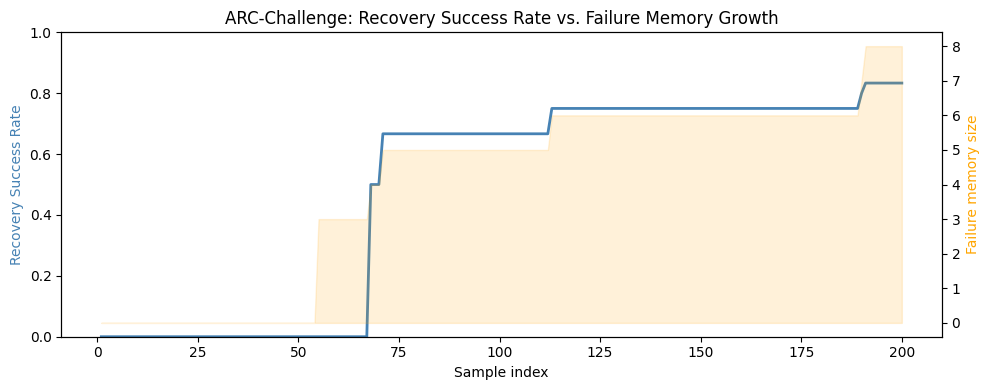

Plot saved to rsr_arc.png


In [25]:

# ═══════════════════════════════════════════════════
# CELL 11 — Plot RSR over time
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt

data = list(csv.DictReader(open("rsr_arc.csv")))
xs   = [int(r["sample"])      for r in data]
rsr  = [float(r["rsr"])       for r in data]
mem  = [int(r["memory_size"]) for r in data]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(xs, rsr, color="steelblue", linewidth=2, label="RSR (rolling)")
ax1.set_xlabel("Sample index")
ax1.set_ylabel("Recovery Success Rate", color="steelblue")
ax1.set_ylim(0, 1)
ax2 = ax1.twinx()
ax2.fill_between(xs, mem, alpha=0.15, color="orange", label="Memory size")
ax2.set_ylabel("Failure memory size", color="orange")
ax1.set_title("ARC-Challenge: Recovery Success Rate vs. Failure Memory Growth")
fig.tight_layout()
plt.savefig("rsr_arc.png", dpi=150)
plt.show()
print("Plot saved to rsr_arc.png")
